Using device: cpu
 Model loaded successfully from /content/drive/MyDrive/Project/unet-resnet34_finetuned.pth


Processing images:   0%|          | 0/15 [00:00<?, ?it/s]

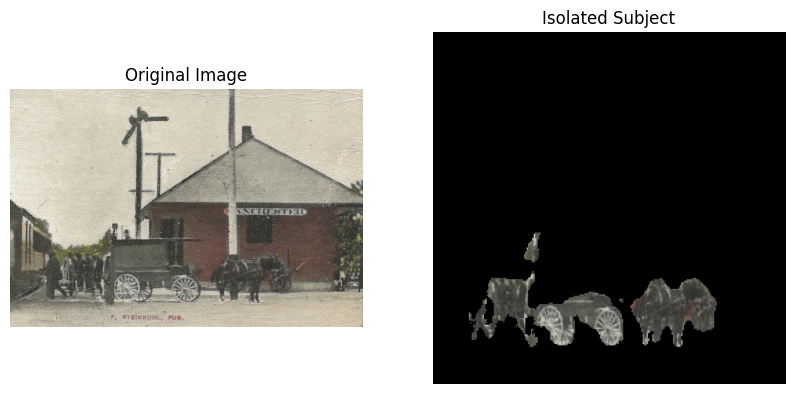

Processing images:   7%|▋         | 1/15 [00:00<00:11,  1.27it/s]

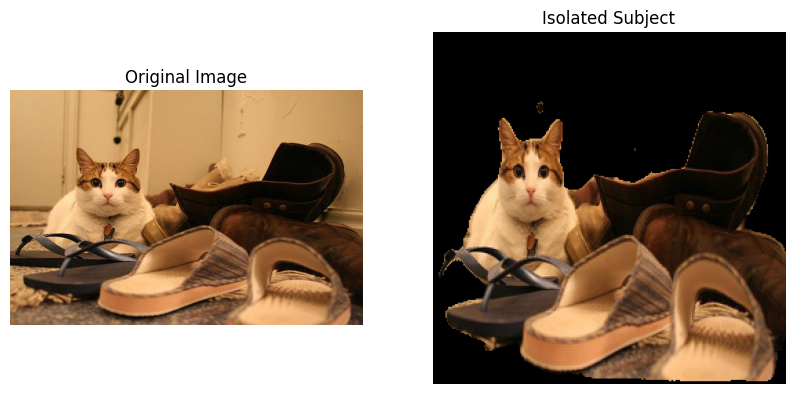

Processing images:  13%|█▎        | 2/15 [00:01<00:09,  1.32it/s]

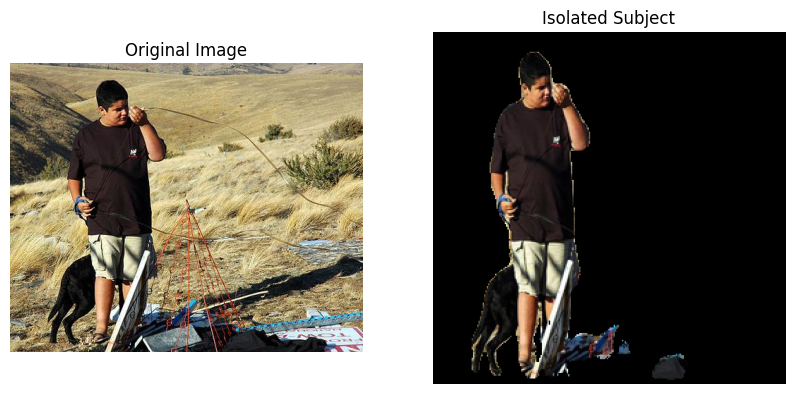

Processing images:  20%|██        | 3/15 [00:02<00:08,  1.48it/s]

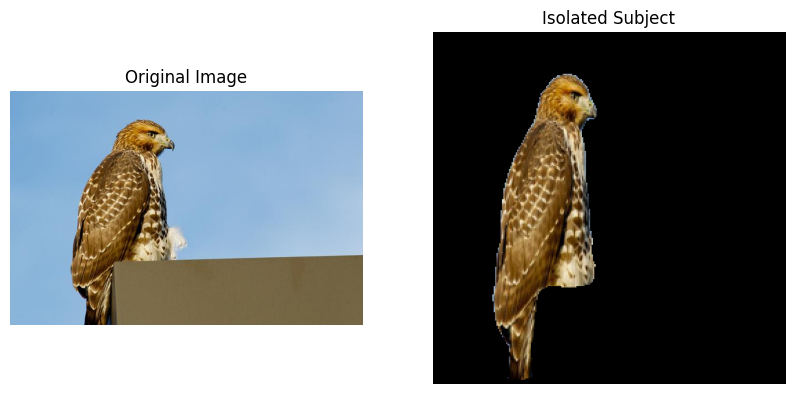

Processing images:  27%|██▋       | 4/15 [00:03<00:09,  1.15it/s]

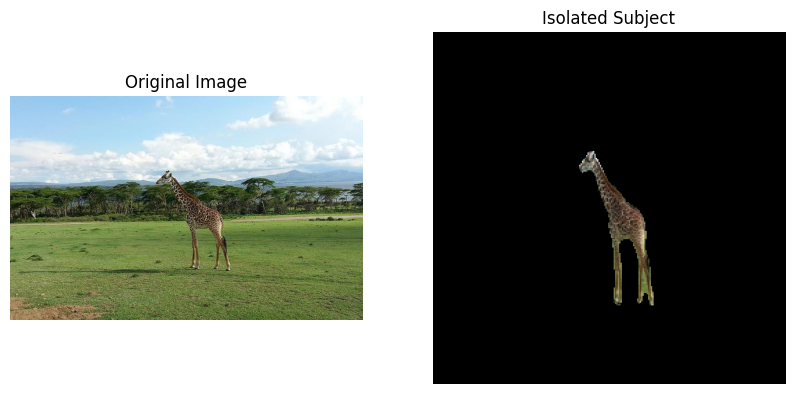

Processing images:  33%|███▎      | 5/15 [00:03<00:07,  1.28it/s]

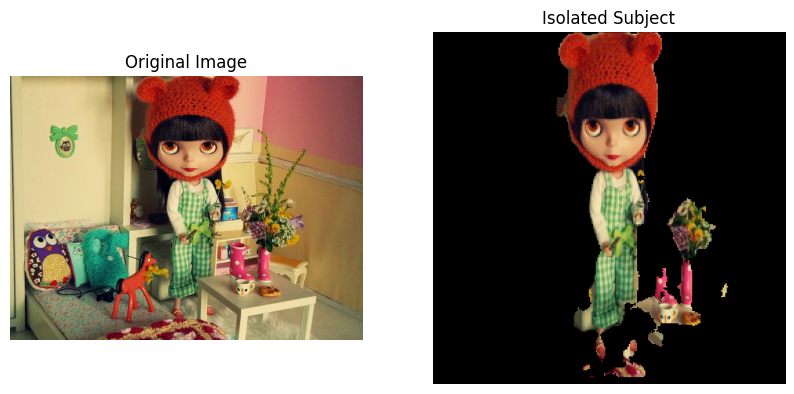

Processing images:  40%|████      | 6/15 [00:04<00:06,  1.40it/s]

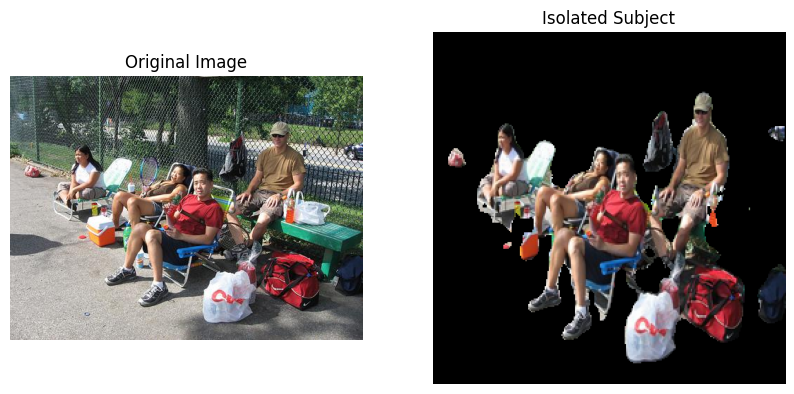

Processing images:  47%|████▋     | 7/15 [00:05<00:05,  1.49it/s]

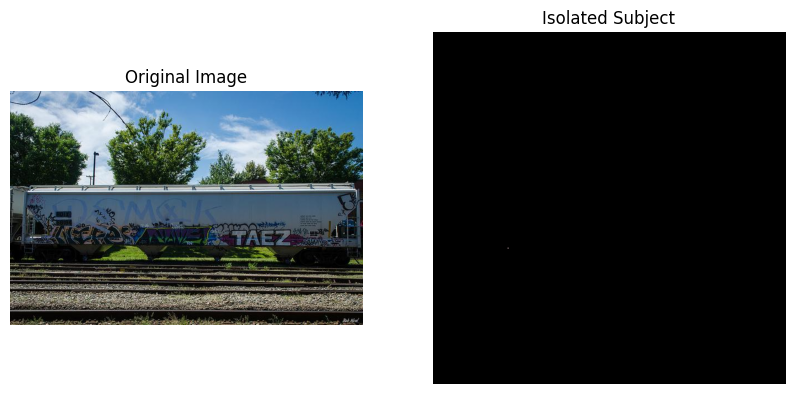

Processing images:  53%|█████▎    | 8/15 [00:05<00:04,  1.57it/s]

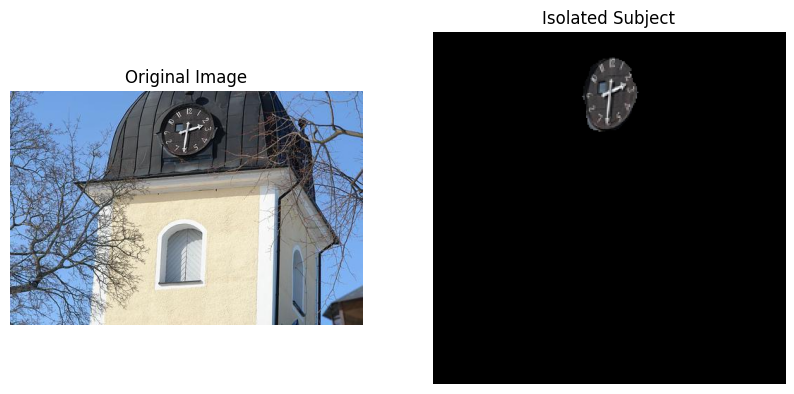

Processing images:  60%|██████    | 9/15 [00:06<00:03,  1.65it/s]

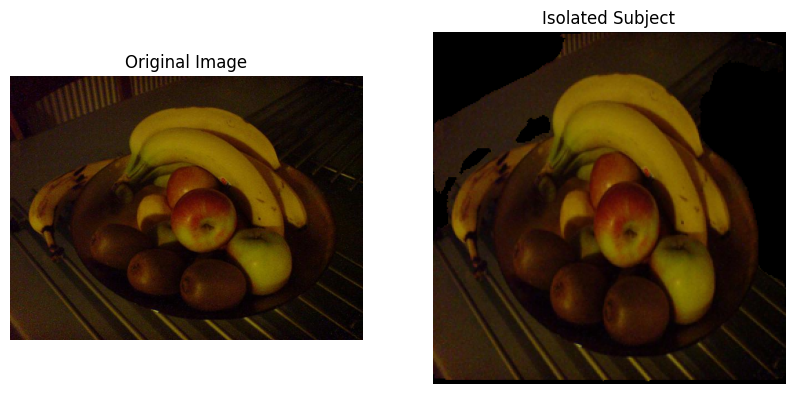

Processing images:  67%|██████▋   | 10/15 [00:06<00:03,  1.57it/s]

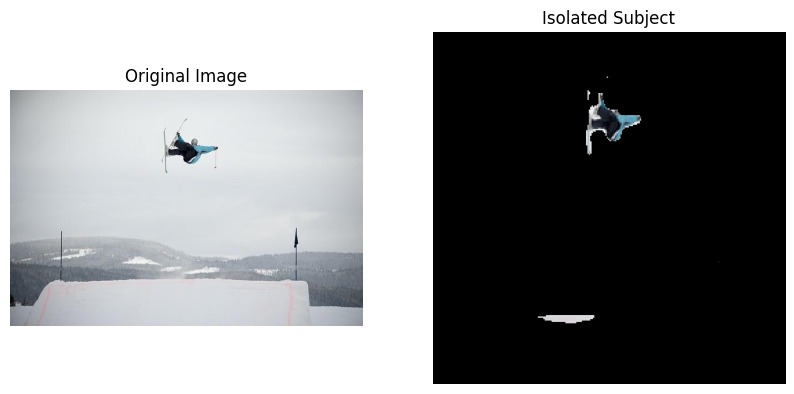

Processing images:  73%|███████▎  | 11/15 [00:07<00:02,  1.62it/s]

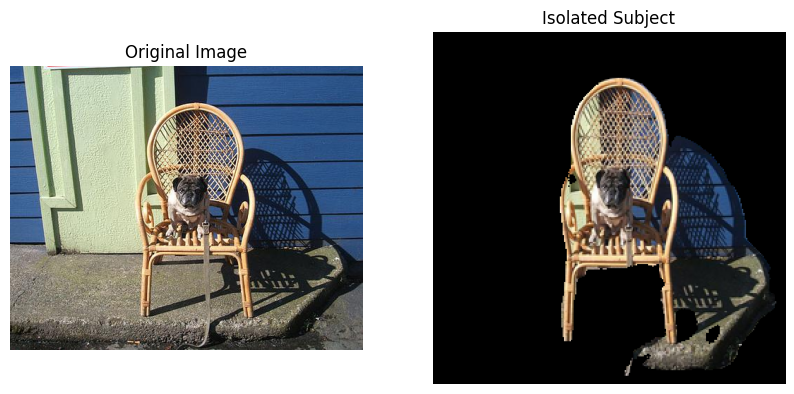

Processing images:  80%|████████  | 12/15 [00:07<00:01,  1.66it/s]

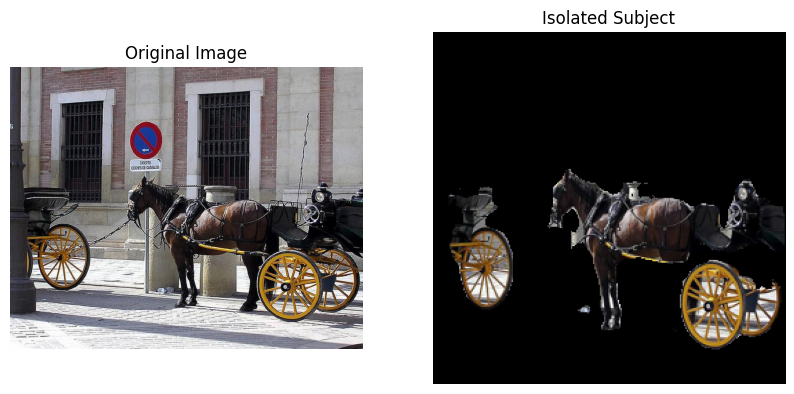

Processing images:  87%|████████▋ | 13/15 [00:08<00:01,  1.63it/s]

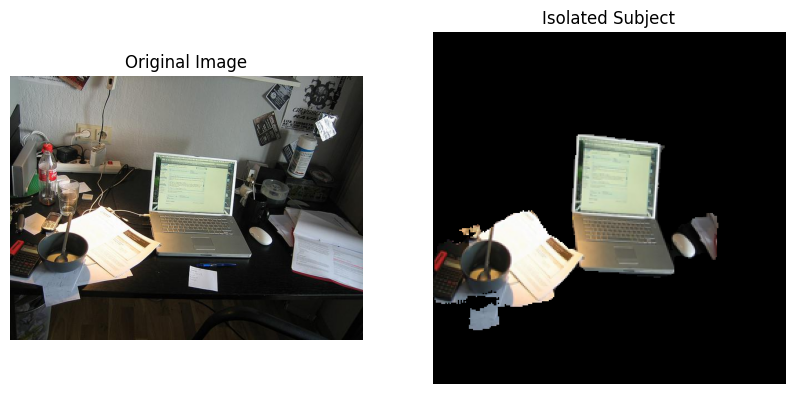

Processing images:  93%|█████████▎| 14/15 [00:09<00:00,  1.63it/s]

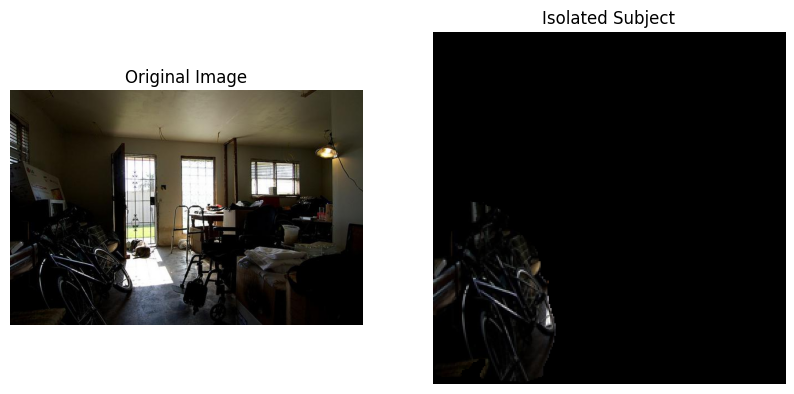

Processing images: 100%|██████████| 15/15 [00:09<00:00,  1.52it/s]


In [8]:
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
import os
from tqdm import tqdm

IMG_SIZE = 256
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

try:
    model = smp.Unet(
        encoder_name="resnet34",
        encoder_weights="imagenet",
        in_channels=3,
        classes=1,
    ).to(device)
except NameError:
    print("Installing segmentation-models-pytorch...")
    !pip install segmentation-models-pytorch -q
    import segmentation_models_pytorch as smp
    model = smp.Unet(
        encoder_name="resnet34",
        encoder_weights="imagenet",
        in_channels=3,
        classes=1,
    ).to(device)

preprocess_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

MODEL_PATH = '/content/drive/MyDrive/Project/unet-resnet34_finetuned.pth'

if not os.path.exists(MODEL_PATH):
    print(f" Error: Model file not found at '{MODEL_PATH}'")
else:
    try:
        model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
        print(f" Model loaded successfully from {MODEL_PATH}")
    except Exception as e:
        print(f" Error loading model weights: {e}")
model.eval()

def isolate_subject(image_path):
    try:
        original_image = Image.open(image_path).convert("RGB")
    except FileNotFoundError:
        print(f" Error: Image not found at {image_path}")
        return None, None

    input_tensor = preprocess_transform(original_image)
    input_batch = input_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_batch)
        pred_mask = (torch.sigmoid(output) > 0.5).float().cpu()

    original_resized = original_image.resize((IMG_SIZE, IMG_SIZE))
    original_tensor = transforms.ToTensor()(original_resized)
    isolated_subject_tensor = original_tensor * pred_mask.squeeze(0)
    isolated_subject_image = transforms.ToPILImage()(isolated_subject_tensor)

    return original_image, isolated_subject_image

FOLDER_TO_PROCESS = '/content/drive/MyDrive/Project/Testdataset'

if not os.path.exists(FOLDER_TO_PROCESS):
    print(f"Error: Folder not found at '{FOLDER_TO_PROCESS}'")
else:
    image_files = [f for f in os.listdir(FOLDER_TO_PROCESS) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    for image_file in tqdm(image_files, desc="Processing images"):
        image_path = os.path.join(FOLDER_TO_PROCESS, image_file)

        original, result = isolate_subject(image_path)

        if original and result:
            fig, axes = plt.subplots(1, 2, figsize=(10, 5))

            axes[0].imshow(original)
            axes[0].set_title("Original Image")
            axes[0].axis('off')

            axes[1].imshow(result)
            axes[1].set_title("Isolated Subject")
            axes[1].axis('off')

            plt.show()